In [1]:
import pandas as pd

from src.grid import GridEnvironment
from src.search import (
    bfs,
    greedy_best_first_search,
    a_star_search,
    uniform_cost_search,
)
from src.heuristics import (
    zero_heuristic,
    manhattan_distance,
    weighted_manhattan_distance,
)
from src.metrics import (
    measure_execution_time,
    benchmark_algorithm,
    summarize_results
)
from src.visualization import (
    print_grid,
    plot_grid,
    print_terrain,
    plot_bar_metric,
)
from src.experiments import (
    generate_solvable_grid,
    run_single_experiment,
    run_configured_experiment,
)
from src.config import GridExperimentConfig
from src.visualization import (
    plot_benchmark_metric
)


c:\Users\niush\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
rows = 30
cols = 30

start = (0,0)
goal = (29,29)

obstacle_probability = 0.2

In [3]:
grid = generate_solvable_grid(
    rows,
    cols,
    obstacle_probability,
    start,
    goal,
    bfs,
)

In [4]:
algorithms = [
    (
        "BFS",
        bfs,
        {}
    ),

    (
        "UCS",
        uniform_cost_search,
        {}
    ),

    (
        "Greedy",
        greedy_best_first_search,
        {
            "heuristic": manhattan_distance
        }
    ),

    (
        "A*",
        a_star_search,
        {
            "heuristic": manhattan_distance
        }
    ),
]

In [5]:
results = run_single_experiment(
    environment=grid,
    start=start,
    goal=goal,
    algorithms=algorithms,
)

In [6]:
df = pd.DataFrame(results)

df

,Algorithm,Success,Path Length,Path Cost,Nodes Expanded,Nodes Generated,Max Frontier,Execution Time
0,BFS,True,58,58.0,701,701,29,0.004670
1,UCS,True,58,58.0,701,701,29,0.004043
2,Greedy,True,66,66.0,74,133,60,0.000509
3,A*,True,58,58.0,409,461,60,0.002951


On small unweighted grids, BFS and UCS show identical behavior because all edge costs are equal and the search space is limited. Larger randomized environments are used for meaningful scalability analysis.

### Experiment Result Summary

On a 30×30 unweighted grid with 20% obstacles, BFS and UCS produced the same optimal path because all transition costs were equal. A* achieved the same optimal solution while expanding fewer nodes by leveraging the Manhattan heuristic. Greedy Best-First Search explored significantly fewer nodes but returned a longer, non-optimal path, highlighting the trade-off between search efficiency and optimality.

BFS:
Shortest path

UCS:
Cheapest path

A*:
Cheapest path with fewer expansions

Defining Terrain

In [7]:
terrain_costs = {
    (0,1): 1,
    (0,2): 9,
    (0,3): 9,
    (1,0): 1,
    (1,1): 1,
    (1,2): 1,
    (1,3): 1,
}

In [8]:
weighted_grid = GridEnvironment(
    rows=2,
    cols=5,
    terrain_costs=terrain_costs,
)

start = (0,0)
goal = (0,4)

In [9]:
bfs_result = bfs(
    weighted_grid,
    start,
    goal,
)


ucs_result = uniform_cost_search(
    weighted_grid,
    start,
    goal,
)


greedy_result = greedy_best_first_search(
    weighted_grid,
    start,
    goal,
    manhattan_distance,
)


astar_result = a_star_search(
    weighted_grid,
    start,
    goal,
    manhattan_distance,
)

In [10]:
results = {
    "BFS": bfs_result,
    "UCS": ucs_result,
    "Greedy": greedy_result,
    "A*": astar_result,
}


for name, result in results.items():

    print(name)

    print(
        "Path:",
        result.path
    )

    print(
        "Depth:",
        result.solution_depth
    )

    print(
        "Cost:",
        result.path_cost
    )

    print()

BFS
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]
Depth: 4
Cost: 20.0

UCS
Path: [(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (0, 4)]
Depth: 6
Cost: 6.0

Greedy
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]
Depth: 4
Cost: 20.0

A*
Path: [(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (1, 4), (0, 4)]
Depth: 6
Cost: 6.0



In [11]:
print_terrain(weighted_grid)

1.0 1 9 9 1.0
1 1 1 1 1.0


### Weighted Grid Experiment Summary

The weighted grid experiment highlights the difference between minimizing path length and minimizing path cost. BFS and Greedy Best-First Search selected the shorter geometric route, resulting in a higher total cost. UCS and A* successfully avoided expensive cells and found a lower-cost solution. This demonstrates why cost-aware algorithms are required for weighted environments.

**Making Config**

In [12]:
config = GridExperimentConfig(
    rows=30,
    cols=30,
    obstacle_probability=0.2,
    start=(0,0),
    goal=(29,29),
    trials=5,
)

To generate a valid dataset, we use BFS as a tool to detect the solvability of the environment.

Why did we choose BFS for this task?

Because BFS:</br>
    It is complete.</br>
    It finds a path in an unweighted grid if it exists.</br>
    It is simple and reliable.

In [13]:
results = run_configured_experiment(
    config,
    algorithms,
    bfs,
)

In [14]:
df = pd.DataFrame(results)

df

,Algorithm,Success,Path Length,Path Cost,Nodes Expanded,Nodes Generated,Max Frontier,Execution Time,Trial,Grid Size,Obstacle Probability
0,BFS,True,58,58.0,725,726,29,0.003843,0,30x30,0.2
1,UCS,True,58,58.0,725,726,29,0.004379,0,30x30,0.2
2,Greedy,True,68,68.0,87,147,61,0.000616,0,30x30,0.2
3,A*,True,58,58.0,556,603,60,0.003581,0,30x30,0.2
4,BFS,True,58,58.0,719,719,30,0.003412,1,30x30,0.2
5,UCS,True,58,58.0,719,719,30,0.004377,1,30x30,0.2
6,Greedy,True,60,60.0,78,138,61,0.000551,1,30x30,0.2
7,A*,True,58,58.0,548,591,57,0.003411,1,30x30,0.2
8,BFS,True,58,58.0,716,716,29,0.003436,2,30x30,0.2
9,UCS,True,58,58.0,716,716,29,0.004569,2,30x30,0.2


In [15]:
summary = (
    df
    .groupby("Algorithm")
    [
        [
            "Path Cost",
            "Nodes Expanded",
            "Execution Time",
        ]
    ]
    .mean()
)

summary

,Path Cost,Nodes Expanded,Execution Time
Algorithm,,,
A*,58.0,523.0,0.003318
BFS,58.0,723.0,0.003513
Greedy,65.2,77.0,0.000572
UCS,58.0,723.0,0.004360


In [16]:
summary = summarize_results(df)

summary

,Algorithm,Success,Path Cost,Nodes Expanded,Nodes Generated,Execution Time
0,A*,1.0,58.0,523.0,576.0,0.003318
1,BFS,1.0,58.0,723.0,723.2,0.003513
2,Greedy,1.0,65.2,77.0,136.6,0.000572
3,UCS,1.0,58.0,723.0,723.2,0.004360


<h1> Experiment Size Creation </h1>

In [17]:
grid_sizes = [
    10,
    20,
    30,
    50,
    75,
]

In [18]:
size_results = []

for size in grid_sizes:

    config = GridExperimentConfig(
        rows=size,
        cols=size,
        obstacle_probability=0.2,
        start=(0,0),
        goal=(size-1,size-1),
        trials=5,
    )

    results = run_configured_experiment(
        config,
        algorithms,
        bfs,
    )

    for result in results:
        result["Grid Dimension"] = size

    size_results.extend(results)

In [19]:
size_df = pd.DataFrame(
    size_results
)

size_df.head()

,Algorithm,Success,Path Length,Path Cost,Nodes Expanded,Nodes Generated,Max Frontier,Execution Time,Trial,Grid Size,Obstacle Probability,Grid Dimension
0,BFS,True,20,20.0,78,79,8,0.000676,0,10x10,0.2,10
1,UCS,True,20,20.0,78,79,8,0.000758,0,10x10,0.2,10
2,Greedy,True,28,28.0,35,51,17,0.000375,0,10x10,0.2,10
3,A*,True,20,20.0,58,62,7,0.000612,0,10x10,0.2,10
4,BFS,True,18,18.0,88,88,12,0.000420,1,10x10,0.2,10


In [20]:
size_df.to_csv(
    "results/grid_size_experiment.csv",
    index=False,
)

In [21]:
size_summary = (
    size_df
    .groupby(
        [
            "Grid Dimension",
            "Algorithm"
        ]
    )
    [
        [
            "Success",
            "Nodes Expanded",
            "Execution Time",
            "Path Cost",
        ]
    ]
    .mean()
    .reset_index()
)

size_summary

,Grid Dimension,Algorithm,Success,Nodes Expanded,Execution Time,Path Cost
0,10,A*,1.0,69.2,0.000623,18.4
1,10,BFS,1.0,81.0,0.000506,18.4
2,10,Greedy,1.0,29.2,0.000260,23.6
3,10,UCS,1.0,81.0,0.000682,18.4
4,20,A*,1.0,233.6,0.001560,38.4
5,20,BFS,1.0,320.6,0.001512,38.4
6,20,Greedy,1.0,46.2,0.000335,41.6
7,20,UCS,1.0,320.6,0.001895,38.4
8,30,A*,1.0,507.4,0.003157,58.0
9,30,BFS,1.0,725.4,0.003415,58.0


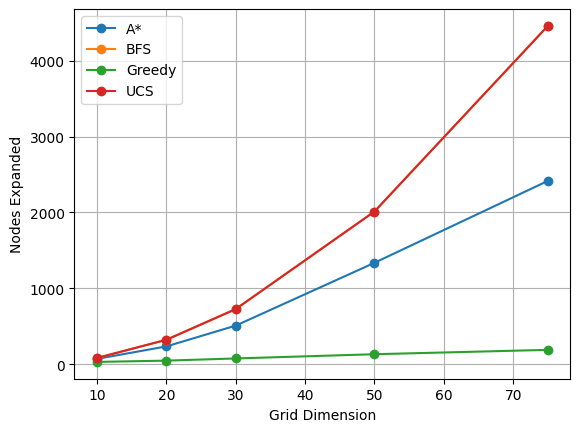

In [22]:
plot_benchmark_metric(
    size_summary,
    "Grid Dimension",
    "Nodes Expanded",
)

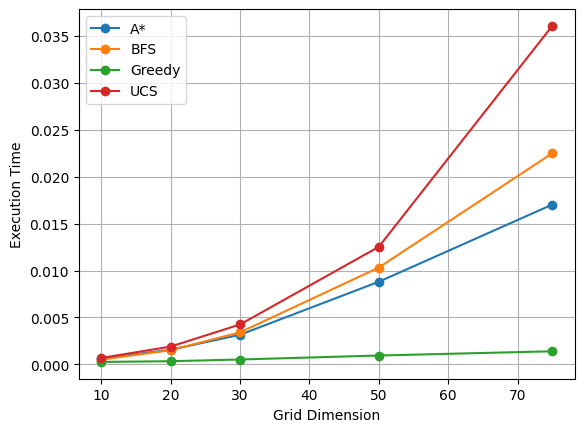

In [23]:
plot_benchmark_metric(
    size_summary,
    "Grid Dimension",
    "Execution Time",
)

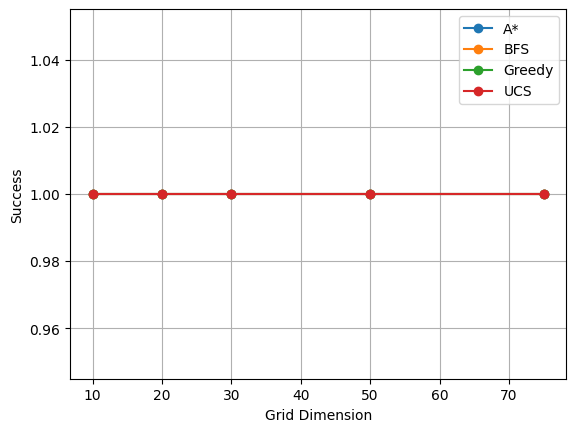

In [24]:
plot_benchmark_metric(
    size_summary,
    "Grid Dimension",
    "Success",
)

Investigating the effect of obstacle percentage on algorithm performance.

In [25]:
densities = [
    0.1,
    0.2,
    0.3,
    # 0.4,
]

In [26]:
density_results = []

for density in densities:

    config = GridExperimentConfig(
        rows=50,
        cols=50,
        obstacle_probability=density,
        start=(0,0),
        goal=(49,49),
        trials=5,
    )

    results = run_configured_experiment(
        config,
        algorithms,
        bfs,
    )

    for result in results:
        result["Obstacle Density"] = density

    density_results.extend(results)

In [27]:
density_df = pd.DataFrame(
    density_results
)

density_df.head()

,Algorithm,Success,Path Length,Path Cost,Nodes Expanded,Nodes Generated,Max Frontier,Execution Time,Trial,Grid Size,Obstacle Probability,Obstacle Density
0,BFS,True,98,98.0,2266,2266,50,0.013176,0,50x50,0.1,0.1
1,UCS,True,98,98.0,2266,2266,50,0.018137,0,50x50,0.1,0.1
2,Greedy,True,102,102.0,104,213,110,0.000871,0,50x50,0.1,0.1
3,A*,True,98,98.0,1957,2047,127,0.014595,0,50x50,0.1,0.1
4,BFS,True,98,98.0,2244,2244,49,0.012012,1,50x50,0.1,0.1


In [28]:
density_summary = (
    density_df
    .groupby(
        [
            "Obstacle Density",
            "Algorithm"
        ]
    )
    [
        [
            "Success",
            "Path Cost",
            "Nodes Expanded",
            "Execution Time",
        ]
    ]
    .mean()
    .reset_index()
)

In [29]:
density_df.to_csv(
    "results/obstacle_density_experiment.csv",
    index=False,
)

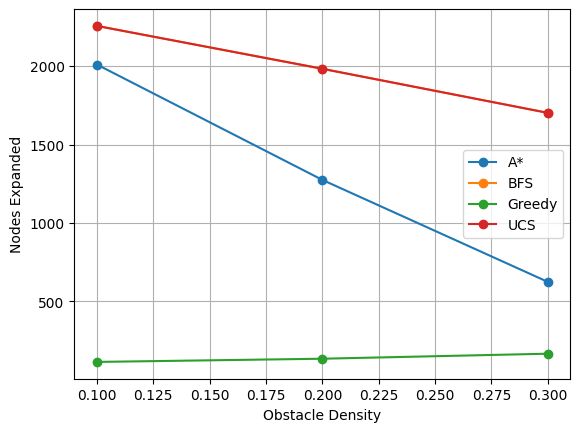

In [30]:
plot_benchmark_metric(
    density_summary,
    "Obstacle Density",
    "Nodes Expanded",
)

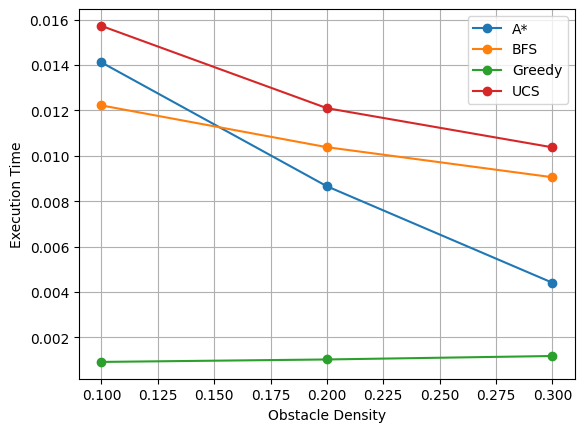

In [31]:
plot_benchmark_metric(
    density_summary,
    "Obstacle Density",
    "Execution Time",
)

<h1> Heuristic Experiment Design </h1>

Here we will not use the previous algorithms anymore.
Because the goal of this Experiment is not to compare different Algorithms. The goal is to compare the quality of Heuristic in a fixed Algorithm

In [32]:
astar_variants = [

    (
        "A*_Zero",
        a_star_search,
        {
            "heuristic": zero_heuristic
        }
    ),

    (
        "A*_Manhattan",
        a_star_search,
        {
            "heuristic": manhattan_distance
        }
    ),

    (
        "A*_Weighted",
        a_star_search,
        {
            "heuristic": weighted_manhattan_distance
        }
    ),
]

In [33]:
config = GridExperimentConfig(
    rows=50,
    cols=50,
    obstacle_probability=0.2,
    start=(0,0),
    goal=(49,49),
    trials=20,
)

In [34]:
heuristic_results = run_configured_experiment(
    config,
    astar_variants,
    bfs,
)

In [35]:
heuristic_df = pd.DataFrame(
    heuristic_results
)

heuristic_df.head()

,Algorithm,Success,Path Length,Path Cost,Nodes Expanded,Nodes Generated,Max Frontier,Execution Time,Trial,Grid Size,Obstacle Probability
0,A*_Zero,True,98,98.0,1959,1959,52,0.020785,0,50x50,0.2
1,A*_Manhattan,True,98,98.0,1194,1289,106,0.021963,0,50x50,0.2
2,A*_Weighted,True,106,106.0,120,215,96,0.002236,0,50x50,0.2
3,A*_Zero,True,98,98.0,1962,1962,51,0.015151,1,50x50,0.2
4,A*_Manhattan,True,98,98.0,758,856,103,0.004967,1,50x50,0.2


In [36]:
heuristic_df.to_csv(
    "results/heuristic_experiment.csv",
    index=False,
)

In [37]:
heuristic_summary = (
    heuristic_df
    .groupby(
        "Algorithm"
    )
    [
        [
            "Success",
            "Path Cost",
            "Nodes Expanded",
            "Execution Time",
            "Max Frontier",
        ]
    ]
    .mean()
    .reset_index()
)

heuristic_summary

,Algorithm,Success,Path Cost,Nodes Expanded,Execution Time,Max Frontier
0,A*_Manhattan,1.0,98.1,1302.55,0.009707,140.75
1,A*_Weighted,1.0,107.9,149.30,0.001231,102.70
2,A*_Zero,1.0,98.1,1991.40,0.012910,48.95


A* is not just an algorithm; it is a framework that is tuned with heuristics.

### Weighted A* Analysis

Weighted A* increases the influence of the heuristic function by multiplying the Manhattan distance by a factor greater than one. This makes the search more aggressive toward the goal, significantly reducing node expansions and execution time. However, this improvement comes at the cost of optimality because the heuristic may overestimate the remaining cost.

In this experiment, Weighted A* expanded far fewer nodes than standard A* but produced a higher-cost path, demonstrating the trade-off between search efficiency and solution optimality.

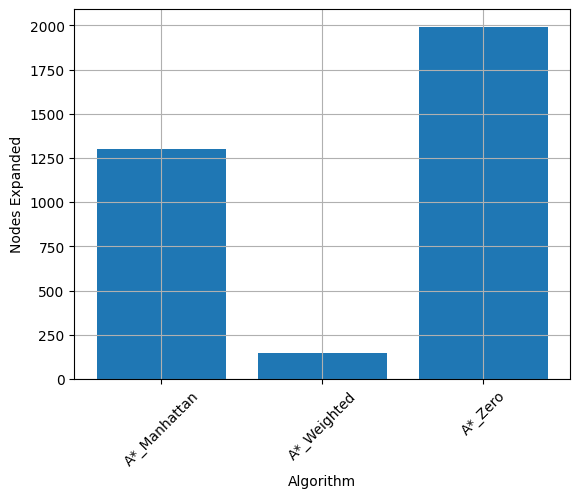

In [38]:
plot_bar_metric(
    heuristic_summary,
    "Algorithm",
    "Nodes Expanded",
)

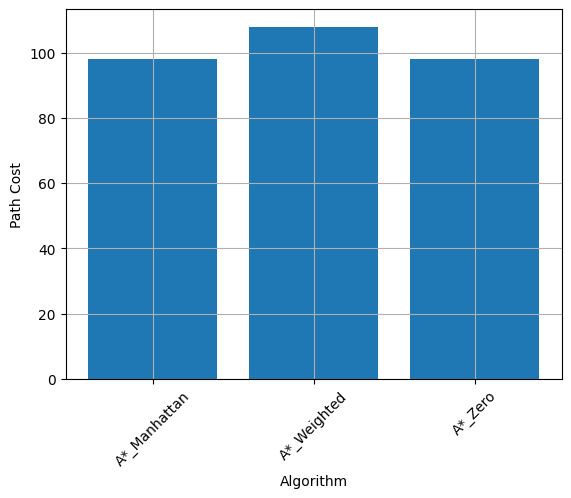

In [39]:
plot_bar_metric(
    heuristic_summary,
    "Algorithm",
    "Path Cost",
)

### Heuristic Experiment Summary

The experiment demonstrates the impact of heuristic design on A* performance. With a zero heuristic, A* behaves similarly to Uniform Cost Search and explores a larger portion of the search space. Manhattan distance improves efficiency by guiding the search while maintaining optimality. Weighted heuristics can reduce exploration further but may sacrifice optimality if the heuristic overestimates the remaining cost.